In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
 


In [6]:
df = pd.read_csv("d://Mining Sector//files//mining_company_data.csv")
df["HireDate"]  = pd.to_datetime(df["HireDate"],  errors="coerce")
df["ShiftDate"] = pd.to_datetime(df["ShiftDate"], errors="coerce")
 
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 130, "axes.titlesize": 13, "axes.labelsize": 11})

In [8]:
prod_df = df[(df["OreExtracted"] > 0) & (df["HoursWorked"] > 0)].copy()
prod_df["OrePerHour"] = prod_df["OreExtracted"] / prod_df["HoursWorked"]
productivity = prod_df.groupby("OreType")["OrePerHour"].mean().sort_values(ascending=False)
print("Productivity (ore/hr) by ore type:")
print(productivity.round(2).to_string())
 


Productivity (ore/hr) by ore type:
OreType
Diamond    70.99
Gold       70.60
Coal       70.31
Iron       69.31
Copper     65.94


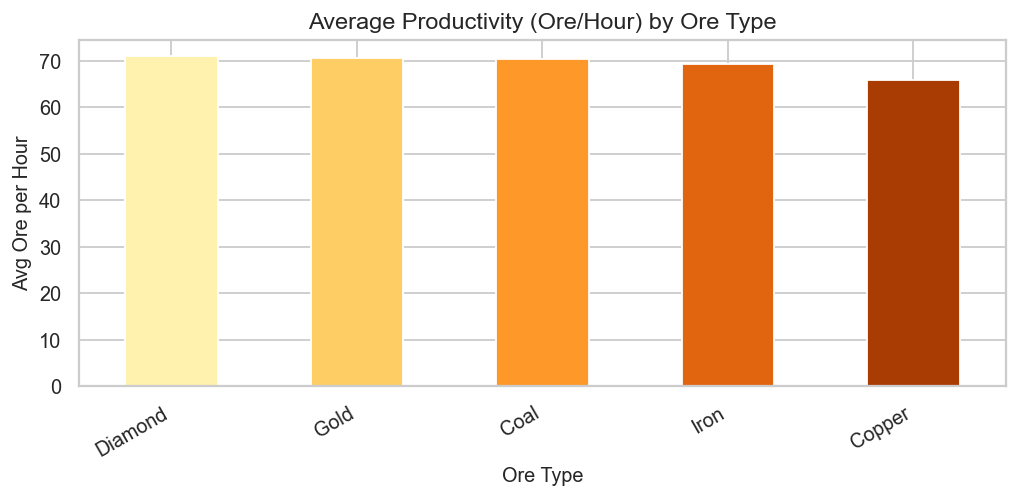

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))
productivity.plot(kind="bar", ax=ax, color=sns.color_palette("YlOrBr", len(productivity)), edgecolor="white")
ax.set_title("Average Productivity (Ore/Hour) by Ore Type")
ax.set_xlabel("Ore Type")
ax.set_ylabel("Avg Ore per Hour")
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")
plt.tight_layout()
